## Data Collection

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import PchipInterpolator

FILE_PATH = "Bloomberg - Historical Data v2026-04-16.xlsx"

TENORS_LABEL = ['2Y', '3Y', '5Y', '10Y', '15Y', '20Y', '30Y']
TENORS_NUM   = [2, 3, 5, 10, 15, 20, 30] 

def get_data(sheet_name):
    TARGET_TENORS = ['date','2Y', '3Y', '5Y', '10Y', '15Y', '20Y', '30Y']
    result_df =pd.read_excel(FILE_PATH, sheet_name=sheet_name)
    result_df.columns = TARGET_TENORS
    result_df = result_df.dropna(subset=TARGET_TENORS)
    result_df = result_df.reset_index(drop=True)
    return result_df
result_usd = get_data("usd sofr results")
result_gbp = get_data("gbp ois results")
result_eur = get_data("eur estr results")

{'gbp ois results': ['BPSWS2 Curncy', 'BPSWS3 Curncy', 'BPSWS5 Curncy', 'BPSWS10 Curncy', 'BPSWS15 Curncy', 'BPSWS20 Curncy', 'BPSWS30 Curncy'], 'eur estr results': ['EESWE2 Curncy', 'EESWE3 Curncy', 'EESWE5 Curncy', 'EESWE10 Curncy', 'EESWE15 Curncy', 'EESWE20 Curncy', 'EESWE30 Curncy'], 'usd sofr results': ['USOSFR2 Curncy', 'USOSFR3 Curncy', 'USOSFR5 Curncy', 'USOSFR10 Curncy', 'USOSFR15 Curncy', 'USOSFR20 Curncy', 'USOSFR30 Curncy']}


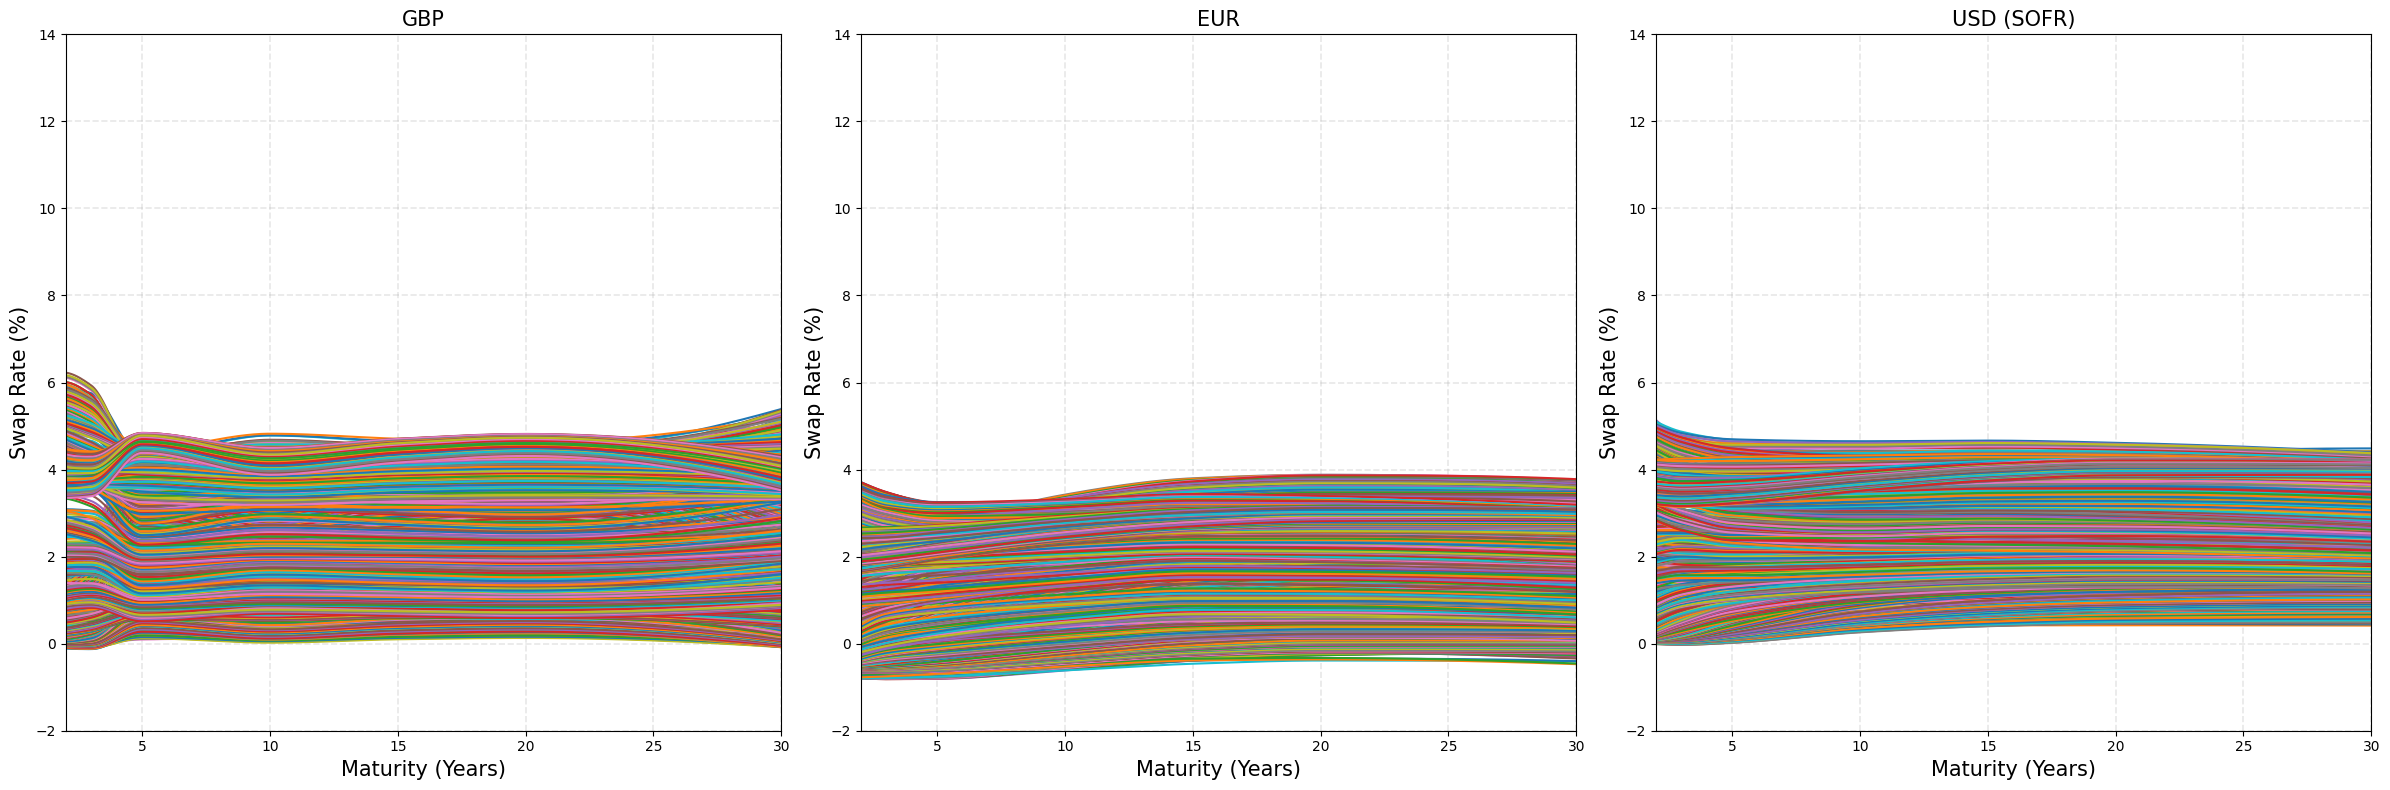

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8)) 

datasets = [
    (result_gbp, "GBP"),
    (result_eur, "EUR"),
    (result_usd, "USD (SOFR)")
]

x_smooth = np.linspace(2, 30, 500)
x_fine = np.linspace(2, 30, 200)
for ax, (df, currency_name) in zip(axes, datasets):
    for _, row in df.iterrows():
        rates = [row[t] for t in TENORS_LABEL]
        
        if any(pd.isna(rates)):
            continue
        x_smooth = np.linspace(2, 30, 500)
        f = PchipInterpolator(TENORS_NUM, rates)
        y_smooth = f(x_smooth)
        
        ax.plot(x_smooth, y_smooth)

    ax.set_title(f"{currency_name}", fontsize=15)
    ax.set_xlabel("Maturity (Years)", fontsize=15)
    ax.set_ylabel("Swap Rate (%)", fontsize=15)

    ax.set_xlim(2, 30)
    ax.set_ylim(-2, 14)
    ax.grid(True, linewidth=1.2,alpha=0.3, linestyle="--")

plt.tight_layout()
plt.savefig('fig/original_data_visual.png', dpi=150)
plt.show()